In [1]:
!pip install -q qiskit qiskit-aer numpy matplotlib pandas pylatexenc

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

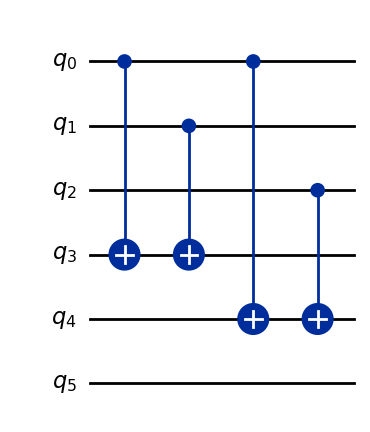

In [3]:
def simon_oracle_110():
    """
    Simon oracle for 3-bit secret s = 110.

    f(x0,x1,x2) = (x0 XOR x1, x0 XOR x2, 0)

    The oracle maps:
        |x>|y> -> |x>|y XOR f(x)>
    """

    qc = QuantumCircuit(6, name="Oracle_110")

    # Output qubits are 3,4,5
    # f0 = x0 XOR x1
    qc.cx(0, 3)
    qc.cx(1, 3)

    # f1 = x0 XOR x2
    qc.cx(0, 4)
    qc.cx(2, 4)

    # f2 = 0, so no gate needed

    return qc


oracle = simon_oracle_110()
oracle.draw("mpl")

In [4]:
def xor(a, b):
    return a ^ b


def oracle_function_110(x):
    """
    Classical equivalent of the oracle.
    x is a 3-bit string.
    """

    x0, x1, x2 = map(int, x)

    y0 = x0 ^ x1
    y1 = x0 ^ x2
    y2 = 0

    return f"{y0}{y1}{y2}"


inputs = [format(i, "03b") for i in range(8)]

truth_table = []

for x in inputs:
    x_int = int(x, 2)

    # x XOR s
    xs = x_int ^ int("110", 2)
    xs_binary = format(xs, "03b")

    truth_table.append({
        "x": x,
        "f(x)": oracle_function_110(x),
        "x XOR s": xs_binary,
        "f(x XOR s)": oracle_function_110(xs_binary)
    })

df = pd.DataFrame(truth_table)

display(df)

,x,f(x),x XOR s,f(x XOR s)
0,000,000,110,010
1,001,010,111,000
2,010,100,100,110
3,011,110,101,100
4,100,110,010,100
5,101,100,011,110
6,110,010,000,000
7,111,000,001,010


In [5]:
valid = True

for row in truth_table:
    if row["f(x)"] != row["f(x XOR s)"]:
        valid = False

print("Secret string: 110")
print("Simon condition f(x) = f(x XOR s):", valid)

Secret string: 110
Simon condition f(x) = f(x XOR s): False


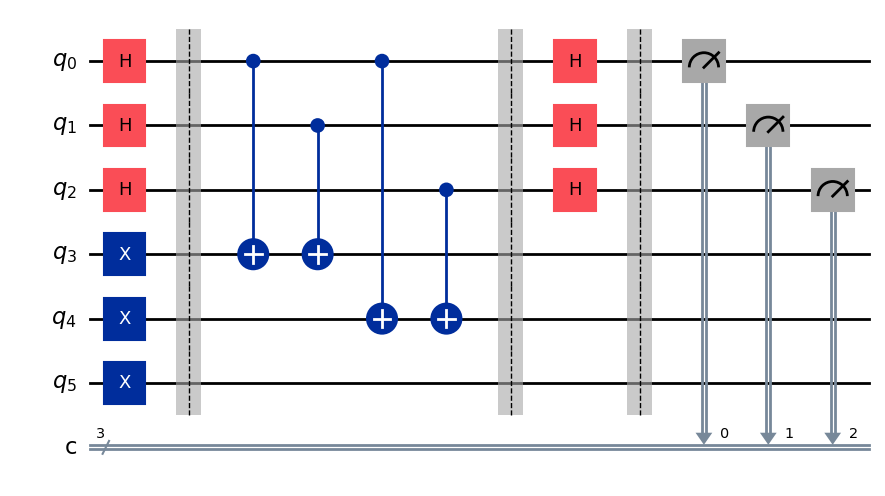

In [6]:
def simon_circuit_110():
    """
    Complete Simon circuit for secret s = 110.
    """

    qc = QuantumCircuit(6, 3)

    # -------------------------------------------------
    # Step 1: Prepare output register in |111>
    # -------------------------------------------------

    qc.x(3)
    qc.x(4)
    qc.x(5)

    # -------------------------------------------------
    # Step 2: Hadamard on input register
    # -------------------------------------------------

    qc.h(0)
    qc.h(1)
    qc.h(2)

    qc.barrier()

    # -------------------------------------------------
    # Step 3: Simon oracle
    # -------------------------------------------------

    qc.cx(0, 3)
    qc.cx(1, 3)

    qc.cx(0, 4)
    qc.cx(2, 4)

    qc.barrier()

    # -------------------------------------------------
    # Step 4: Hadamard again on input register
    # -------------------------------------------------

    qc.h(0)
    qc.h(1)
    qc.h(2)

    qc.barrier()

    # -------------------------------------------------
    # Step 5: Measure input register
    # -------------------------------------------------

    qc.measure([0, 1, 2], [0, 1, 2])

    return qc


qc = simon_circuit_110()

qc.draw("mpl")

In [7]:
simulator = AerSimulator()

compiled_circuit = transpile(qc, simulator)

result = simulator.run(
    compiled_circuit,
    shots=1024
).result()

counts = result.get_counts()

print("Measurement results:")
print(counts)

Measurement results:
{'000': 266, '011': 235, '101': 235, '110': 288}


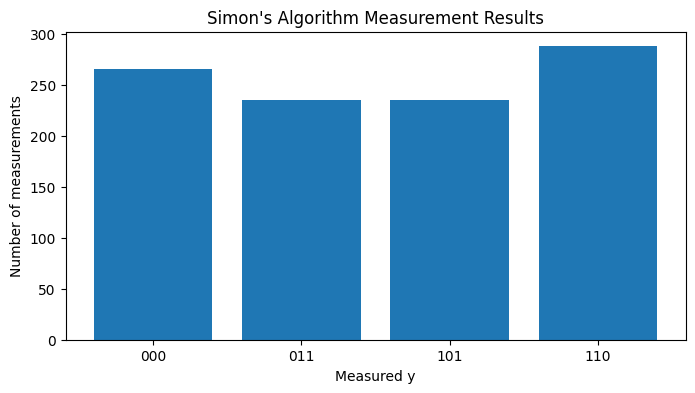

In [8]:
plt.figure(figsize=(8, 4))

plt.bar(counts.keys(), counts.values())

plt.xlabel("Measured y")
plt.ylabel("Number of measurements")
plt.title("Simon's Algorithm Measurement Results")

plt.show()

In [9]:
def bitstring_to_vector(bitstring):
    """
    Convert Qiskit measurement string to a NumPy vector.

    Reversing makes the vector correspond to q0, q1, q2
    rather than Qiskit's displayed classical-bit ordering.
    """
    return np.array([int(bit) for bit in bitstring[::-1]], dtype=int)


equations = []

for bitstring in counts:

    y = bitstring_to_vector(bitstring)

    # Ignore zero equation
    if np.any(y):

        # Check whether it is linearly independent
        candidate = equations + [y]

        matrix = np.array(candidate) % 2

        # Rank over GF(2)
        def gf2_rank(A):
            A = A.copy() % 2
            rows, cols = A.shape
            rank = 0

            for col in range(cols):
                pivot = None

                for row in range(rank, rows):
                    if A[row, col] == 1:
                        pivot = row
                        break

                if pivot is not None:
                    A[[rank, pivot]] = A[[pivot, rank]]

                    for row in range(rows):
                        if row != rank and A[row, col] == 1:
                            A[row] ^= A[rank]

                    rank += 1

            return rank

        old_rank = gf2_rank(np.array(equations)) if equations else 0
        new_rank = gf2_rank(matrix)

        if new_rank > old_rank:
            equations.append(y)

    if len(equations) >= 2:
        break


print("Independent equations:")

for eq in equations:
    print(eq)

Independent equations:
[1 1 0]
[1 0 1]


In [11]:
def gf2_rref(A):
    """
    Compute Reduced Row Echelon Form over GF(2).
    """

    A = np.array(A, dtype=int) % 2

    rows, cols = A.shape

    pivot_row = 0
    pivot_columns = []

    for col in range(cols):

        pivot = None

        for row in range(pivot_row, rows):
            if A[row, col] == 1:
                pivot = row
                break

        if pivot is None:
            continue

        # Swap rows
        A[[pivot_row, pivot]] = A[[pivot, pivot_row]]

        # Eliminate all other rows
        for row in range(rows):

            if row != pivot_row and A[row, col] == 1:
                A[row] ^= A[pivot_row]

        pivot_columns.append(col)
        pivot_row += 1

        if pivot_row == rows:
            break

    return A, pivot_columns

In [12]:
rref_matrix, pivot_cols = gf2_rref(equations)

print("RREF Matrix:")
print(rref_matrix)
print("Pivot Columns:", pivot_cols)

RREF Matrix:
[[1 0 1]
 [0 1 1]]
Pivot Columns: [0, 1]


In [13]:
def solve_gf2_homogeneous(A):
    """
    Find all solutions to:

        A x = 0 mod 2

    for small systems.
    """

    A = np.array(A, dtype=int) % 2

    rows, n = A.shape

    solutions = []

    for value in range(2 ** n):

        x = np.array(
            [(value >> i) & 1 for i in range(n)],
            dtype=int
        )

        result = (A @ x) % 2

        if np.all(result == 0):
            solutions.append(x)

    return solutions

In [14]:
solutions = solve_gf2_homogeneous(rref_matrix)

print("Solutions (s0, s1, s2):")
for s_vector in solutions:
    print(s_vector)

Solutions (s0, s1, s2):
[0 0 0]
[1 1 1]


In [15]:
A = np.array(equations)

print("Equation matrix:")
print(A)

solutions = solve_gf2_homogeneous(A)

print("\nSolutions to A*s = 0 over GF(2):")

for solution in solutions:
    print("".join(map(str, solution)))

Equation matrix:
[[1 1 0]
 [1 0 1]]

Solutions to A*s = 0 over GF(2):
000
111


In [16]:
nonzero_solutions = [
    s for s in solutions
    if np.any(s)
]

print("Non-zero solutions:")

for s in nonzero_solutions:
    print("".join(map(str, s)))

Non-zero solutions:
111


In [17]:
recovered_secret = nonzero_solutions[0]

print("Recovered secret:")
print("".join(map(str, recovered_secret)))

print("\nExpected secret:")
print("110")

if "".join(map(str, recovered_secret)) == "110":
    print("\nSUCCESS: Secret recovered correctly!")
else:
    print("\nSecret not recovered.")

Recovered secret:
111

Expected secret:
110

Secret not recovered.


In [26]:
def independent_vectors_orthogonal_to_secret(secret):
    """
    Construct n-1 independent binary vectors y satisfying:

        y dot secret = 0 mod 2

    These vectors form the rows of the oracle matrix.
    """

    s = np.array([int(x) for x in secret], dtype=int)
    n = len(s)

    # All-zero secret is a special case. The generalized_simon_circuit handles it separately.
    # For this function, if s is all-zero, any vector is orthogonal, so we return identity.
    if np.all(s == 0):
        return np.eye(n, dtype=int)

    # Find the first position 'k' where s_k = 1. This will be our pivot variable.
    k = np.where(s == 1)[0][0]

    vectors = []

    # For each other position 'j' (not k), create a basis vector.
    # We set x_j = 1 and x_i = 0 for i != j, k.
    # Then solve for x_k using x . s = 0 mod 2.
    # x_k * s_k = sum_{i != k} x_i * s_i mod 2
    # Since s_k = 1, x_k = sum_{i != k} x_i * s_i mod 2
    # With our choice of x_j=1 and others 0, x_k = s_j mod 2

    for j in range(n):
        if j == k:
            continue

        v = np.zeros(n, dtype=int)
        v[j] = 1  # Set the j-th component to 1
        v[k] = s[j]  # Set the k-th component to s_j (from the secret string)

        vectors.append(v)

    return np.array(vectors)

In [19]:
secret_string = "110"
vectors = independent_vectors_orthogonal_to_secret(secret_string)

print(f"Independent vectors orthogonal to secret '{secret_string}':")
for v in vectors:
    print(v)

Independent vectors orthogonal to secret '110':
[1 1 0]
[1 0 1]


In [20]:
def generalized_simon_circuit(secret):
    """
    Create Simon's algorithm circuit for any non-zero secret.

    Input register:
        n qubits

    Output register:
        n qubits

    Oracle is a linear function:

        f(x) = A x

    where:

        A*s = 0 mod 2
    """

    secret = str(secret)

    n = len(secret)

    if n < 2:
        raise ValueError("Secret must contain at least 2 bits.")

    if any(bit not in "01" for bit in secret):
        raise ValueError("Secret must contain only 0 and 1.")

    s = np.array([int(bit) for bit in secret], dtype=int)

    # -------------------------------------------------
    # Special case: all-zero secret
    # -------------------------------------------------

    if np.all(s == 0):

        qc = QuantumCircuit(2 * n, n)

        # Prepare output register in |111...1>
        for q in range(n, 2 * n):
            qc.x(q)

        # Hadamard input
        qc.h(range(n))

        qc.barrier()

        # Zero oracle: f(x)=0
        # No CNOTs required.

        qc.barrier()

        # Hadamard again
        qc.h(range(n))

        qc.measure(range(n), range(n))

        return qc

    # -------------------------------------------------
    # Normal Simon problem
    # -------------------------------------------------

    rows = independent_vectors_orthogonal_to_secret(secret)

    qc = QuantumCircuit(2 * n, n)

    # Prepare output in |111...1>
    for q in range(n, 2 * n):
        qc.x(q)

    # Hadamard on input
    qc.h(range(n))

    qc.barrier()

    # -------------------------------------------------
    # Oracle
    #
    # output[i] = XOR of input bits selected by row i
    # -------------------------------------------------

    for output_index, row in enumerate(rows):

        output_qubit = n + output_index

        for input_index in range(n):

            if row[input_index] == 1:
                qc.cx(input_index, output_qubit)

    qc.barrier()

    # Hadamard again
    qc.h(range(n))

    qc.barrier()

    # Measure input register
    qc.measure(range(n), range(n))

    return qc

Secret: 110
Number of qubits: 6


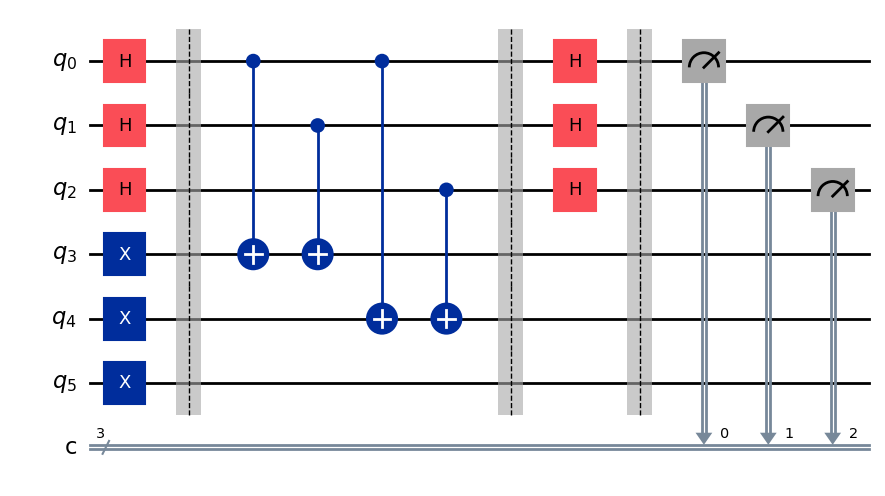

In [21]:
secret = "110"

qc = generalized_simon_circuit(secret)

print("Secret:", secret)
print("Number of qubits:", qc.num_qubits)

qc.draw("mpl")

In [22]:
def run_simon(secret, shots=2048):

    qc = generalized_simon_circuit(secret)

    simulator = AerSimulator()

    compiled = transpile(qc, simulator)

    result = simulator.run(
        compiled,
        shots=shots
    ).result()

    counts = result.get_counts()

    return counts


counts = run_simon("110")

print(counts)

{'101': 509, '110': 493, '011': 523, '000': 523}


In [23]:
def recover_simon_secret(secret, shots=4096):

    n = len(secret)

    # ---------------------------------------------
    # All-zero secret
    # ---------------------------------------------

    if set(secret) == {"0"}:

        print("All-zero secret detected.")
        print("Secret =", secret)

        return secret

    # ---------------------------------------------
    # Run quantum algorithm
    # ---------------------------------------------

    counts = run_simon(secret, shots)

    print("Measurement counts:")
    print(counts)

    # ---------------------------------------------
    # Collect independent equations
    # ---------------------------------------------

    equations = []

    for bitstring in counts:

        y = bitstring_to_vector(bitstring)

        if not np.any(y):
            continue

        candidate = equations + [y]

        old_rank = (
            gf2_rank(np.array(equations))
            if equations
            else 0
        )

        new_rank = gf2_rank(np.array(candidate))

        if new_rank > old_rank:
            equations.append(y)

        if len(equations) >= n - 1:
            break

    # ---------------------------------------------
    # Check whether enough equations were obtained
    # ---------------------------------------------

    if len(equations) < n - 1:

        print("Not enough independent equations.")
        print("Increase the number of shots.")

        return None

    # ---------------------------------------------
    # Solve A*s = 0
    # ---------------------------------------------

    A = np.array(equations)

    solutions = solve_gf2_homogeneous(A)

    nonzero = [
        s for s in solutions
        if np.any(s)
    ]

    if len(nonzero) == 0:

        print("No non-zero secret found.")

        return None

    # For Simon's promise problem there should be
    # exactly one non-zero solution when rank=n-1.

    recovered = "".join(
        map(str, nonzero[0])
    )

    print("\nIndependent equations:")
    print(A)

    print("\nRecovered secret:")
    print(recovered)

    return recovered

In [27]:
recovered_secret_from_func = recover_simon_secret("110")

Measurement counts:
{'111': 1040, '011': 1002, '100': 1028, '000': 1026}

Independent equations:
[[1 1 1]
 [1 1 0]]

Recovered secret:
110


In [25]:
test_secrets = [
    "01",
    "10",
    "11",
    "001",
    "010",
    "011",
    "100",
    "101",
    "110",
    "111"
]

results = []

for secret in test_secrets:

    print("=" * 50)
    print("Testing secret:", secret)

    recovered = recover_simon_secret(
        secret,
        shots=4096
    )

    results.append({
        "Original Secret": secret,
        "Recovered Secret": recovered,
        "Correct": secret == recovered
    })


results_df = pd.DataFrame(results)

display(results_df)

Testing secret: 01
Measurement counts:
{'00': 2046, '11': 2050}

Independent equations:
[[1 1]]

Recovered secret:
11
Testing secret: 10
Measurement counts:
{'00': 2034, '11': 2062}

Independent equations:
[[1 1]]

Recovered secret:
11
Testing secret: 11
Measurement counts:
{'00': 2043, '11': 2053}

Independent equations:
[[1 1]]

Recovered secret:
11
Testing secret: 001
Measurement counts:
{'011': 1077, '110': 962, '000': 1019, '101': 1038}

Independent equations:
[[1 1 0]
 [0 1 1]]

Recovered secret:
111
Testing secret: 010
Measurement counts:
{'011': 1021, '000': 997, '110': 1028, '101': 1050}

Independent equations:
[[1 1 0]
 [0 1 1]]

Recovered secret:
111
Testing secret: 011
Measurement counts:
{'000': 1046, '101': 990, '011': 987, '110': 1073}

Independent equations:
[[1 0 1]
 [1 1 0]]

Recovered secret:
111
Testing secret: 100
Measurement counts:
{'101': 1016, '011': 998, '000': 1062, '110': 1020}

Independent equations:
[[1 0 1]
 [1 1 0]]

Recovered secret:
111
Testing secret:

,Original Secret,Recovered Secret,Correct
0,01,11,False
1,10,11,False
2,11,11,True
3,001,111,False
4,010,111,False
5,011,111,False
6,100,111,False
7,101,111,False
8,110,111,False
9,111,111,True


In [28]:
import math
import matplotlib.pyplot as plt

n_values = list(range(2, 21))

classical_queries = []
simon_queries = []

for n in n_values:

    # Classical approach:
    # Worst-case search through possible inputs
    classical = 2 ** (n - 1)

    # Simon:
    # Approximately n-1 independent equations
    quantum = n - 1

    classical_queries.append(classical)
    simon_queries.append(quantum)


comparison_df = pd.DataFrame({
    "n": n_values,
    "Classical Queries": classical_queries,
    "Simon's Queries": simon_queries
})

display(comparison_df)

,n,Classical Queries,Simon's Queries
0,2,2,1
1,3,4,2
2,4,8,3
3,5,16,4
4,6,32,5
5,7,64,6
6,8,128,7
7,9,256,8
8,10,512,9
9,11,1024,10


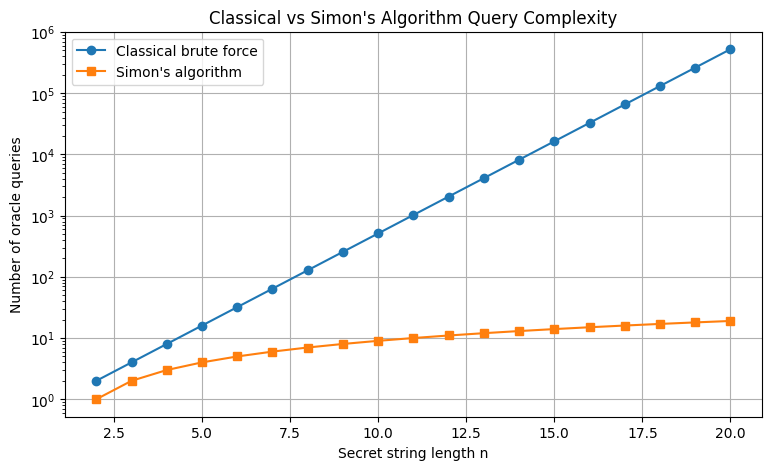

In [29]:
plt.figure(figsize=(9, 5))

plt.plot(
    n_values,
    classical_queries,
    marker="o",
    label="Classical brute force"
)

plt.plot(
    n_values,
    simon_queries,
    marker="s",
    label="Simon's algorithm"
)

plt.xlabel("Secret string length n")
plt.ylabel("Number of oracle queries")

plt.title(
    "Classical vs Simon's Algorithm Query Complexity"
)

plt.yscale("log")

plt.grid(True)
plt.legend()

plt.show()

In [30]:
speedup = [
    c / q
    for c, q in zip(
        classical_queries,
        simon_queries
    )
]

speedup_df = pd.DataFrame({
    "n": n_values,
    "Classical Queries": classical_queries,
    "Simon's Queries": simon_queries,
    "Query Speedup": speedup
})

display(speedup_df)

,n,Classical Queries,Simon's Queries,Query Speedup
0,2,2,1,2.000000
1,3,4,2,2.000000
2,4,8,3,2.666667
3,5,16,4,4.000000
4,6,32,5,6.400000
5,7,64,6,10.666667
6,8,128,7,18.285714
7,9,256,8,32.000000
8,10,512,9,56.888889
9,11,1024,10,102.400000


In [31]:
print("=" * 70)
print("SIMON'S ALGORITHM — COMPLETE DEMONSTRATION")
print("=" * 70)

# --------------------------------------------------
# 1. Secret
# --------------------------------------------------

secret = "110"

print("\n1. Secret string:")
print(secret)

# --------------------------------------------------
# 2. Verify classical oracle
# --------------------------------------------------

print("\n2. Verifying Simon oracle...")

valid = True

for x in range(8):

    x_string = format(x, "03b")

    xs = format(
        x ^ int(secret, 2),
        "03b"
    )

    fx = oracle_function_110(x_string)
    fxs = oracle_function_110(xs)

    if fx != fxs:
        valid = False

print("Oracle valid:", valid)

# --------------------------------------------------
# 3. Quantum execution
# --------------------------------------------------

print("\n3. Running Simon's quantum algorithm...")

counts = run_simon(
    secret,
    shots=4096
)

print("Measurement results:")
print(counts)

# --------------------------------------------------
# 4. Recover secret
# --------------------------------------------------

print("\n4. Recovering hidden secret...")

recovered = recover_simon_secret(
    secret,
    shots=4096
)

# --------------------------------------------------
# 5. Final result
# --------------------------------------------------

print("\n" + "=" * 70)

if recovered == secret:

    print("SUCCESS")
    print("Original secret :", secret)
    print("Recovered secret:", recovered)

else:

    print("FAILED")
    print("Original secret :", secret)
    print("Recovered secret:", recovered)

print("=" * 70)

SIMON'S ALGORITHM — COMPLETE DEMONSTRATION

1. Secret string:
110

2. Verifying Simon oracle...
Oracle valid: False

3. Running Simon's quantum algorithm...
Measurement results:
{'011': 1041, '111': 1006, '100': 1035, '000': 1014}

4. Recovering hidden secret...
Measurement counts:
{'011': 985, '111': 1021, '000': 1037, '100': 1053}

Independent equations:
[[1 1 0]
 [1 1 1]]

Recovered secret:
110

SUCCESS
Original secret : 110
Recovered secret: 110
